In [ ]:
from students.data_processing import (
    load_heart_disease_data,
    preprocess_data,
    prepare_regression_data,
    prepare_classification_data,
    split_and_scale
)
from students.regression import (
    train_elasticnet_grid,
    create_r2_heatmap,
    get_best_elasticnet_model
)
from students.classification import (
    train_logistic_regression_grid,
    train_knn_grid,
    get_best_logistic_regression,
    get_best_knn
)
from students.evaluation import (
    calculate_r2_score,
    calculate_classification_metrics,
    calculate_auroc_score,
    calculate_auprc_score,
    generate_auroc_curve,
    generate_auprc_curve
)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve


# Load and preprocess
df = load_heart_disease_data("data/heart_disease_uci.csv")
df_clean = preprocess_data(df)

print("Cleaned shape:", df_clean.shape)


# =========================
# TASK 1: ELASTICNET
# =========================
X_reg, y_reg = prepare_regression_data(df_clean, target="chol")
X_train_reg, X_test_reg, y_train_reg, y_test_reg, scaler_reg = split_and_scale(
    X_reg, y_reg, test_size=0.2, random_state=42
)

elastic_results = train_elasticnet_grid(
    X_train_reg, y_train_reg,
    l1_ratios=[0.3, 0.5, 0.7],
    alphas=[0.01, 0.1, 1.0]
)

best_elastic = get_best_elasticnet_model(
    X_train_reg, y_train_reg,
    l1_ratios=[0.3, 0.5, 0.7],
    alphas=[0.01, 0.1, 1.0]
)

best_elastic_model = best_elastic["best_model"]
y_pred_reg = best_elastic_model.predict(X_test_reg)
r2_test = calculate_r2_score(y_test_reg, y_pred_reg)

print("\n=== ElasticNet ===")
print("Best params:", best_elastic["best_params"])
print("Best CV score:", best_elastic["best_score"])
print("Test R²:", r2_test)

fig1 = create_r2_heatmap(elastic_results)
plt.show()


# =========================
# TASK 2: LOGISTIC REGRESSION
# =========================
X_clf, y_clf = prepare_classification_data(df_clean, target="num")
X_train_clf, X_test_clf, y_train_clf, y_test_clf, scaler_clf = split_and_scale(
    X_clf, y_clf, test_size=0.2, random_state=42
)

log_grid = train_logistic_regression_grid(X_train_clf, y_train_clf)
best_log = get_best_logistic_regression(X_train_clf, y_train_clf)

best_log_model = best_log["best_model"]
y_pred_log = best_log_model.predict(X_test_clf)
y_score_log = best_log_model.predict_proba(X_test_clf)[:, 1]

log_metrics = calculate_classification_metrics(y_test_clf, y_pred_log)
log_auc = calculate_auroc_score(y_test_clf, y_score_log)
log_ap = calculate_auprc_score(y_test_clf, y_score_log)

print("\n=== Logistic Regression ===")
print("Best params:", best_log["best_params"])
print("Best CV score:", best_log["best_score"])
print("Metrics:", log_metrics)
print("AUROC:", log_auc)
print("AUPRC:", log_ap)

fig2 = generate_auroc_curve(y_test_clf, y_score_log, title="Logistic Regression AUROC")
plt.show()

fig3 = generate_auprc_curve(y_test_clf, y_score_log, title="Logistic Regression AUPRC")
plt.show()


# =========================
# TASK 3: KNN
# =========================
knn_grid = train_knn_grid(X_train_clf, y_train_clf)
best_knn = get_best_knn(X_train_clf, y_train_clf)

best_knn_model = best_knn["best_model"]
y_pred_knn = best_knn_model.predict(X_test_clf)
y_score_knn = best_knn_model.predict_proba(X_test_clf)[:, 1]

knn_metrics = calculate_classification_metrics(y_test_clf, y_pred_knn)
knn_auc = calculate_auroc_score(y_test_clf, y_score_knn)
knn_ap = calculate_auprc_score(y_test_clf, y_score_knn)

print("\n=== k-NN ===")
print("Best params:", best_knn["best_params"])
print("Best CV score:", best_knn["best_score"])
print("Metrics:", knn_metrics)
print("AUROC:", knn_auc)
print("AUPRC:", knn_ap)

fig4 = generate_auroc_curve(y_test_clf, y_score_knn, title="k-NN AUROC")
plt.show()

fig5 = generate_auprc_curve(y_test_clf, y_score_knn, title="k-NN AUPRC")
plt.show()


# =========================
# TASK 4: MODEL COMPARISON
# =========================
fpr_log, tpr_log, _ = roc_curve(y_test_clf, y_score_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test_clf, y_score_knn)

prec_log, rec_log, _ = precision_recall_curve(y_test_clf, y_score_log)
prec_knn, rec_knn, _ = precision_recall_curve(y_test_clf, y_score_knn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {log_auc:.3f}")
axes[0].plot(fpr_knn, tpr_knn, label=f"k-NN AUC = {knn_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("AUROC Comparison")
axes[0].legend(loc="lower right")

axes[1].plot(rec_log, prec_log, label=f"Logistic Regression AP = {log_ap:.3f}")
axes[1].plot(rec_knn, prec_knn, label=f"k-NN AP = {knn_ap:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("AUPRC Comparison")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

c:\Users\oxana\Downloads\assignment-2-supervised-learning-ox7na-main\assignment-2-supervised-learning-ox7na-main\students\data_processing.py:76: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors="ignore")


Cleaned shape: (920, 22)

=== ElasticNet ===
Best params: {'alpha': 0.01, 'l1_ratio': 0.3}
Best CV score: 0.585410682078064
Test R²: 0.5310914288528147


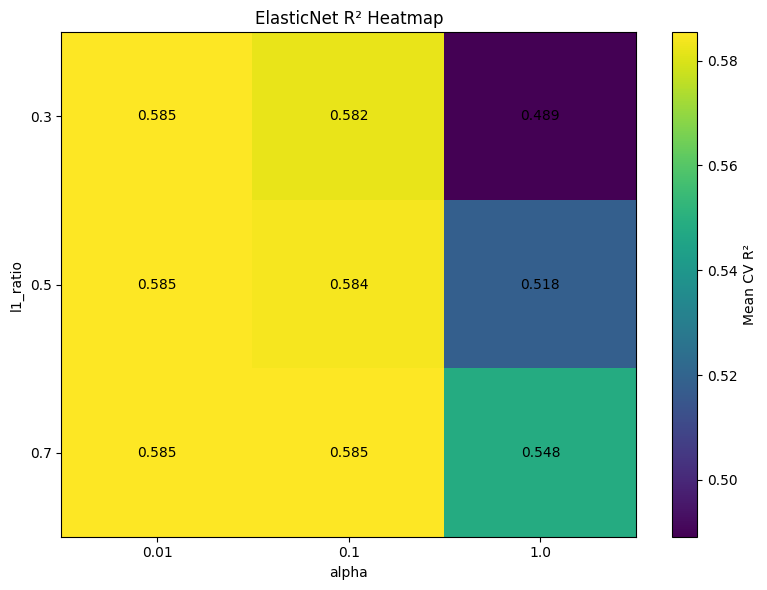


=== Logistic Regression ===
Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV score: 0.9012578849435217
Metrics: {'accuracy': 0.8369565217391305, 'precision': 0.8333333333333334, 'recall': 0.8823529411764706, 'f1': 0.8571428571428571}
AUROC: 0.9214490674318507
AUPRC: 0.9169323909699097


C:\Users\oxana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\oxana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


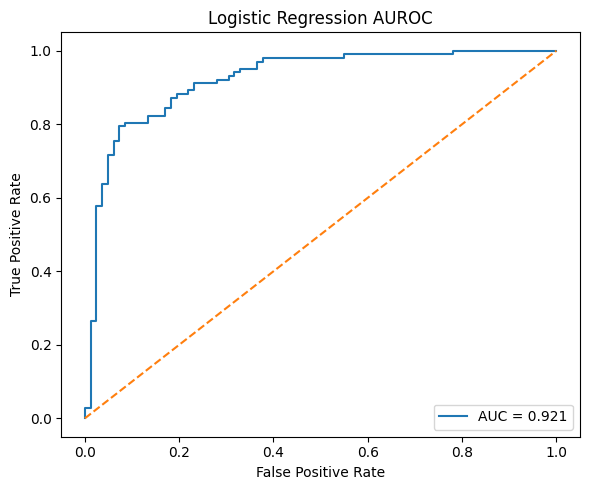

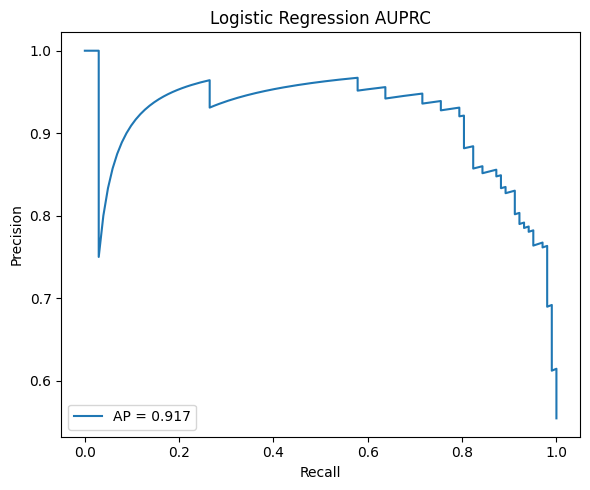


=== k-NN ===
Best params: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
Best CV score: 0.8897744170914901
Metrics: {'accuracy': 0.8641304347826086, 'precision': 0.8532110091743119, 'recall': 0.9117647058823529, 'f1': 0.8815165876777251}
AUROC: 0.9216284074605452
AUPRC: 0.9202853707991725


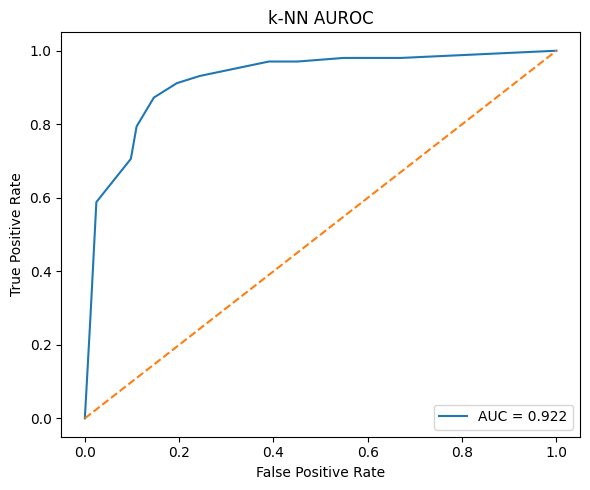

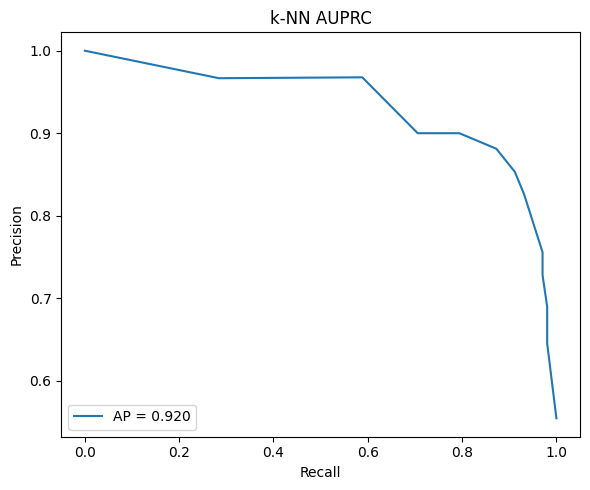

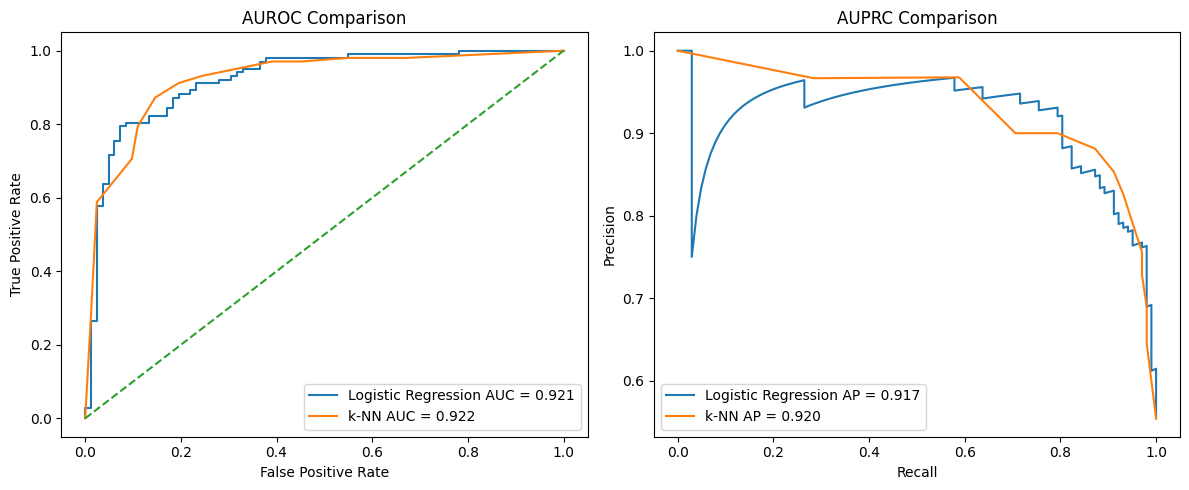

In [4]:
from students.data_processing import (
    load_heart_disease_data,
    preprocess_data,
    prepare_regression_data,
    prepare_classification_data,
    split_and_scale
)
from students.regression import (
    train_elasticnet_grid,
    create_r2_heatmap,
    get_best_elasticnet_model
)
from students.classification import (
    train_logistic_regression_grid,
    train_knn_grid,
    get_best_logistic_regression,
    get_best_knn
)
from students.evaluation import (
    calculate_r2_score,
    calculate_classification_metrics,
    calculate_auroc_score,
    calculate_auprc_score,
    generate_auroc_curve,
    generate_auprc_curve
)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve


# Load and preprocess
df = load_heart_disease_data("data/heart_disease_uci.csv")
df_clean = preprocess_data(df)

print("Cleaned shape:", df_clean.shape)


# =========================
# TASK 1: ELASTICNET
# =========================
X_reg, y_reg = prepare_regression_data(df_clean, target="chol")
X_train_reg, X_test_reg, y_train_reg, y_test_reg, scaler_reg = split_and_scale(
    X_reg, y_reg, test_size=0.2, random_state=42
)

elastic_results = train_elasticnet_grid(
    X_train_reg, y_train_reg,
    l1_ratios=[0.3, 0.5, 0.7],
    alphas=[0.01, 0.1, 1.0]
)

best_elastic = get_best_elasticnet_model(
    X_train_reg, y_train_reg,
    l1_ratios=[0.3, 0.5, 0.7],
    alphas=[0.01, 0.1, 1.0]
)

best_elastic_model = best_elastic["best_model"]
y_pred_reg = best_elastic_model.predict(X_test_reg)
r2_test = calculate_r2_score(y_test_reg, y_pred_reg)

print("\n=== ElasticNet ===")
print("Best params:", best_elastic["best_params"])
print("Best CV score:", best_elastic["best_score"])
print("Test R²:", r2_test)

fig1 = create_r2_heatmap(elastic_results)
plt.show()


# =========================
# TASK 2: LOGISTIC REGRESSION
# =========================
X_clf, y_clf = prepare_classification_data(df_clean, target="num")
X_train_clf, X_test_clf, y_train_clf, y_test_clf, scaler_clf = split_and_scale(
    X_clf, y_clf, test_size=0.2, random_state=42
)

log_grid = train_logistic_regression_grid(X_train_clf, y_train_clf)
best_log = get_best_logistic_regression(X_train_clf, y_train_clf)

best_log_model = best_log["best_model"]
y_pred_log = best_log_model.predict(X_test_clf)
y_score_log = best_log_model.predict_proba(X_test_clf)[:, 1]

log_metrics = calculate_classification_metrics(y_test_clf, y_pred_log)
log_auc = calculate_auroc_score(y_test_clf, y_score_log)
log_ap = calculate_auprc_score(y_test_clf, y_score_log)

print("\n=== Logistic Regression ===")
print("Best params:", best_log["best_params"])
print("Best CV score:", best_log["best_score"])
print("Metrics:", log_metrics)
print("AUROC:", log_auc)
print("AUPRC:", log_ap)

fig2 = generate_auroc_curve(y_test_clf, y_score_log, title="Logistic Regression AUROC")
plt.show()

fig3 = generate_auprc_curve(y_test_clf, y_score_log, title="Logistic Regression AUPRC")
plt.show()


# =========================
# TASK 3: KNN
# =========================
knn_grid = train_knn_grid(X_train_clf, y_train_clf)
best_knn = get_best_knn(X_train_clf, y_train_clf)

best_knn_model = best_knn["best_model"]
y_pred_knn = best_knn_model.predict(X_test_clf)
y_score_knn = best_knn_model.predict_proba(X_test_clf)[:, 1]

knn_metrics = calculate_classification_metrics(y_test_clf, y_pred_knn)
knn_auc = calculate_auroc_score(y_test_clf, y_score_knn)
knn_ap = calculate_auprc_score(y_test_clf, y_score_knn)

print("\n=== k-NN ===")
print("Best params:", best_knn["best_params"])
print("Best CV score:", best_knn["best_score"])
print("Metrics:", knn_metrics)
print("AUROC:", knn_auc)
print("AUPRC:", knn_ap)

fig4 = generate_auroc_curve(y_test_clf, y_score_knn, title="k-NN AUROC")
plt.show()

fig5 = generate_auprc_curve(y_test_clf, y_score_knn, title="k-NN AUPRC")
plt.show()


# =========================
# TASK 4: MODEL COMPARISON
# =========================
fpr_log, tpr_log, _ = roc_curve(y_test_clf, y_score_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test_clf, y_score_knn)

prec_log, rec_log, _ = precision_recall_curve(y_test_clf, y_score_log)
prec_knn, rec_knn, _ = precision_recall_curve(y_test_clf, y_score_knn)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {log_auc:.3f}")
axes[0].plot(fpr_knn, tpr_knn, label=f"k-NN AUC = {knn_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("AUROC Comparison")
axes[0].legend(loc="lower right")

axes[1].plot(rec_log, prec_log, label=f"Logistic Regression AP = {log_ap:.3f}")
axes[1].plot(rec_knn, prec_knn, label=f"k-NN AP = {knn_ap:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("AUPRC Comparison")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()